# 05 — Germany 2018 installed-capacity weighting

**Question.** Does representing where German wind and PV capacity was installed improve the
correspondence between COSMO-REA6 resource proxies and observed national generation?

Notebooks 02–04 use cosine-latitude area weighting: every German grid cell contributes according
to its physical area. That is appropriate for describing Germany's average weather resource, but
not for approximating a generation fleet. This notebook weights each grid cell by mapped installed
capacity instead, producing a **modelled fleet proxy**.

## 1. Meaning of capacity-weighted CF

For technology $k$ and grid cells $i$, the capacity-weighted fleet proxy is

$$CF_k(t)=\frac{\sum_i P_{k,i}CF_{k,i}(t)}{\sum_i P_{k,i}},$$

where $P_{k,i}$ is installed MW mapped to cell $i$. A cell containing twice as much capacity
receives twice the influence. Unlike area weighting, this answers: *what weather did the
installed fleet experience?*

It still does not reproduce actual generation exactly. Every plant in a grid cell receives the
same simplified power curve; turbine model, hub height, panel tilt, availability, wake losses,
curtailment, and grid constraints remain absent.

## 2. Load area-weighted, capacity-weighted, and observed series

In [1]:
%matplotlib inline
from pathlib import Path
import json

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ROOT = Path.cwd()
ASSETS = ROOT / "app_assets" / "2018"

area_all = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_daily_country_timeseries.parquet")
area = area_all[area_all["country"] == "de"][["time", "wind_cf", "solar_cf", "combined_cf"]].copy()
area["time"] = pd.to_datetime(area["time"]).dt.normalize()

capacity = pd.read_parquet(ASSETS / "cosmo_rea6_de_2018_daily_capacity_weighted.parquet")
capacity["time"] = pd.to_datetime(capacity["time"]).dt.normalize()

observed = pd.read_csv(ASSETS / "smard_de_2018_daily.csv", parse_dates=["date"])
observed["date"] = pd.to_datetime(observed["date"]).dt.tz_localize(None).dt.normalize()

with open(ASSETS / "cosmo_rea6_de_2018_capacity_weighting_qc.json", encoding="utf-8") as handle:
    qc = json.load(handle)

comparison = area.merge(capacity, on="time").merge(observed, left_on="time", right_on="date")
integrity = pd.Series({
    "area unique dates": area["time"].nunique(),
    "capacity unique dates": capacity["time"].nunique(),
    "SMARD unique dates": observed["date"].nunique(),
    "matched dates": comparison["time"].nunique(),
    "duplicate matched dates": int(comparison["time"].duplicated().sum()),
    "missing analysis values": int(comparison.isna().sum().sum()),
    "capacity-weighted CF minimum": capacity.filter(like="cf_").min().min(),
    "capacity-weighted CF maximum": capacity.filter(like="cf_").max().max(),
}, name="pre-analysis integrity check")
integrity

area unique dates               365.000000
capacity unique dates           365.000000
SMARD unique dates              365.000000
matched dates                   365.000000
duplicate matched dates           0.000000
missing analysis values           0.000000
capacity-weighted CF minimum      0.000241
capacity-weighted CF maximum      0.873454
Name: pre-analysis integrity check, dtype: float64

## 3. Plant-register coverage and limitations

**Open Power System Data (OPSD)** is an open-data platform that harmonizes power-system data.
Its 2020-08-25 German renewable-power-plant register has one record per registered unit. The
processing script actually reads electrical capacity, energy source, technology, longitude,
latitude, commissioning date, decommissioning date, and federal state. It filters onshore wind
and PV with positive capacity and valid coordinates that were operating at some time in 2018,
then maps each coordinate to the nearest COSMO-REA6 grid-cell centre inside Germany. No plant
identifier or status field is used by this analysis.

A **record count** says how many register rows survived; it does not say how much of the national
MW fleet is represented. A million small PV records can contain similar total MW to far fewer
wind records. Capacity coverage therefore compares summed mapped MW with published end-2018 MW.

The weights are a **static 2018 snapshot**: a plant commissioned late in 2018 receives the same
weight throughout the year. This avoids false precision but creates temporal mismatch. Missing
or invalid coordinates reduce mapped capacity, particularly for wind. Coverage must therefore
be quantified before interpreting model skill.

In [2]:
coverage = pd.DataFrame({
    "mapped plant records": qc["plant_records"],
    "mapped capacity MW": qc["mapped_capacity_mw"],
    "published end-2018 MW": qc["published_end_2018_capacity_mw"],
    "capacity coverage": qc["mapped_capacity_coverage_fraction"],
    "occupied COSMO cells": qc["occupied_grid_cells"],
}).loc[["wind", "solar"]]
coverage

,mapped plant records,mapped capacity MW,published end-2018 MW,capacity coverage,occupied COSMO cells
wind,21511,42185.939,52565,0.8026,2376
solar,1724519,44008.608,45277,0.9720,5582


Wind coverage is materially weaker than solar coverage. The mapped wind result represents the
spatial distribution of coordinate-valid plants, not the entire German fleet. PV coordinates
are often postcode or municipality centroids rather than rooftop coordinates, which is adequate
for a ~6 km weather grid but should not be mistaken for site-level geolocation.

## 4. Where capacity enters the spatial average

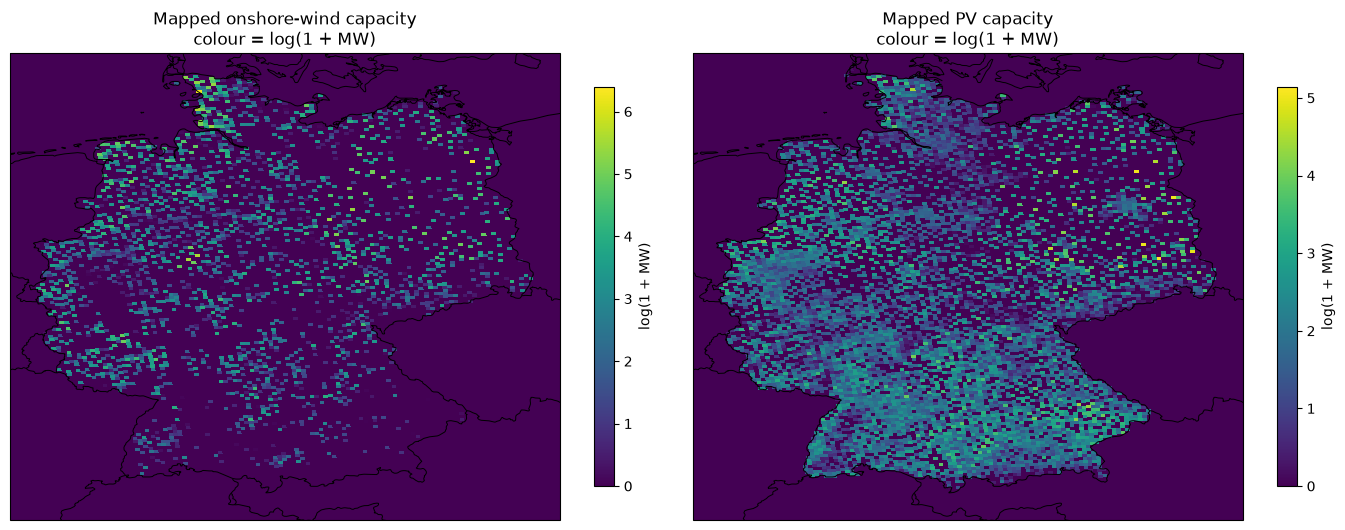

In [3]:
weights = xr.open_dataset(ASSETS / "cosmo_rea6_de_capacity_weights_2018.nc")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, variable, title in zip(
    axes,
    ["wind_capacity_mw", "solar_capacity_mw"],
    ["Mapped onshore-wind capacity", "Mapped PV capacity"],
):
    plotted = np.log1p(weights[variable]).plot(
        ax=ax, x="longitude", y="latitude", transform=ccrs.PlateCarree(),
        cmap="viridis", add_colorbar=False,
    )
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.set_extent([5.5, 15.5, 47.0, 55.5])
    ax.set_title(f"{title}\ncolour = log(1 + MW)")
    fig.colorbar(plotted, ax=ax, shrink=0.7, label="log(1 + MW)")
plt.tight_layout()
plt.show()

The colour is $\log(1+MW)$, a transform that keeps zero defined and prevents a few very large
cells from hiding smaller ones. Concrete natural-log examples are: 0 MW → 0, 9 MW → about
2.30, and 99 MW → about 4.61. A colour step of the same size therefore represents a
multiplicative, not additive, capacity change. Visual colour differences are logarithmic and
must not be read as direct MW differences; use the underlying data for exact capacity.

**Interpretation.** Wind capacity is concentrated in northern and central Germany, where the
resource is stronger and less obstructed. PV is much more dispersed, although southern and
populated regions remain visible. We therefore expect capacity weighting to affect wind more
strongly than solar.

## 5. Area weighting versus capacity weighting

In [4]:
means = pd.DataFrame({
    "area weighted": [comparison["wind_cf"].mean(), comparison["solar_cf_x"].mean()],
    "capacity weighted": [comparison["wind_cf_capacity_weighted"].mean(), comparison["solar_cf_capacity_weighted"].mean()],
    "SMARD observed": [comparison["wind_onshore_cf"].mean(), comparison["solar_cf_y"].mean()],
}, index=["wind", "solar"])
means["capacity minus area"] = means["capacity weighted"] - means["area weighted"]
means.round(3)

,area weighted,capacity weighted,SMARD observed,capacity minus area
wind,0.155,0.205,0.194,0.05
solar,0.128,0.128,0.104,0.00


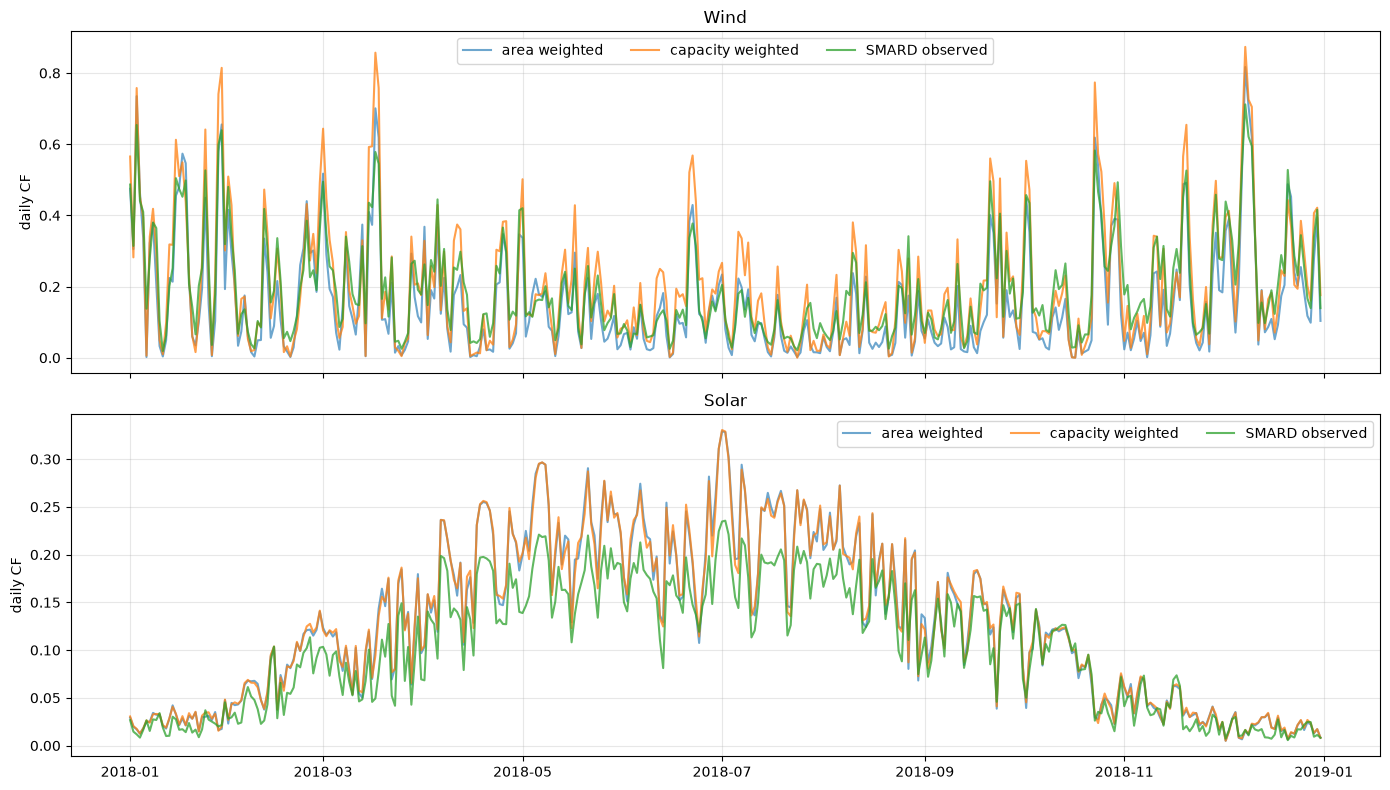

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
series = [
    ("wind_cf", "wind_cf_capacity_weighted", "wind_onshore_cf", "Wind"),
    ("solar_cf_x", "solar_cf_capacity_weighted", "solar_cf_y", "Solar"),
]
for ax, (area_col, capacity_col, observed_col, title) in zip(axes, series):
    ax.plot(comparison["time"], comparison[area_col], label="area weighted", alpha=0.65)
    ax.plot(comparison["time"], comparison[capacity_col], label="capacity weighted", alpha=0.75)
    ax.plot(comparison["time"], comparison[observed_col], label="SMARD observed", alpha=0.75)
    ax.set_ylabel("daily CF")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(ncol=3)
plt.tight_layout()
plt.show()

**How to read the daily comparison.** First compare timing: peaks, troughs, and crossings that
occur on the same dates indicate shared weather timing. Then compare amplitude: persistent
vertical separation shows a level difference even when timing is good. Overlap means two
estimates agree for that day; repeated crossings mean neither is uniformly higher.

For wind, capacity weighting can move the national curve more because turbines are clustered
in a subset of generally windier northern and central cells; area weighting also gives influence
to large regions with little installed wind. PV is geographically more dispersed across the
model cells, so its capacity-weighted and area-weighted curves tend to differ less. SMARD remains
actual national generation, so neither proxy is expected to overlap it perfectly.

## 6. Does capacity weighting improve validation?

Correlation assesses timing; bias measures mean level error; MAE measures typical absolute
daily error; RMSE penalizes large misses. Improvement should be judged across all metrics—not
from annual mean alone.

In [6]:
def metrics(observed_series, modelled):
    error = modelled - observed_series
    return {
        "mean CF": modelled.mean(),
        "correlation": modelled.corr(observed_series),
        "bias": error.mean(),
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt(np.mean(error**2)),
    }

validation = pd.DataFrame({
    ("wind", "area"): metrics(comparison["wind_onshore_cf"], comparison["wind_cf"]),
    ("wind", "capacity"): metrics(comparison["wind_onshore_cf"], comparison["wind_cf_capacity_weighted"]),
    ("solar", "area"): metrics(comparison["solar_cf_y"], comparison["solar_cf_x"]),
    ("solar", "capacity"): metrics(comparison["solar_cf_y"], comparison["solar_cf_capacity_weighted"]),
}).T
validation.index.names = ["technology", "weighting"]
validation.round(3)

mean CF  correlation   bias    MAE   RMSE
technology weighting                                           
wind       area         0.155        0.945 -0.039  0.053  0.064
           capacity     0.205        0.940  0.011  0.052  0.067
solar      area         0.128        0.980  0.024  0.026  0.034
           capacity     0.128        0.983  0.024  0.025  0.033

In [7]:
improvement = pd.DataFrame({
    "absolute bias reduction": [
        abs(validation.loc[("wind", "area"), "bias"]) - abs(validation.loc[("wind", "capacity"), "bias"]),
        abs(validation.loc[("solar", "area"), "bias"]) - abs(validation.loc[("solar", "capacity"), "bias"]),
    ],
    "MAE reduction": [
        validation.loc[("wind", "area"), "MAE"] - validation.loc[("wind", "capacity"), "MAE"],
        validation.loc[("solar", "area"), "MAE"] - validation.loc[("solar", "capacity"), "MAE"],
    ],
    "correlation change": [
        validation.loc[("wind", "capacity"), "correlation"] - validation.loc[("wind", "area"), "correlation"],
        validation.loc[("solar", "capacity"), "correlation"] - validation.loc[("solar", "area"), "correlation"],
    ],
}, index=["wind", "solar"])
improvement.round(3)

,absolute bias reduction,MAE reduction,correlation change
wind,0.028,0.001,-0.004
solar,-0.000,0.000,0.003


**2018 interpretation.** Capacity weighting largely removes the wind mean bias (−0.039 becomes
+0.011 CF), confirming that installed wind geography matters. It does **not** uniformly improve
daily skill: wind MAE changes only slightly, correlation declines by about 0.004, and RMSE
increases because some large daily errors are amplified. For solar, the annual mean barely
changes, while correlation, MAE, and RMSE improve slightly. This pattern shows that spatial
weighting addresses fleet location but cannot repair the generic conversion curves or
day-specific operational differences.

## 7. Portfolio implications and low-output events

In [8]:
comparison["hybrid_area"] = 0.5 * comparison["wind_cf"] + 0.5 * comparison["solar_cf_x"]
comparison["hybrid_capacity"] = 0.5 * comparison["wind_cf_capacity_weighted"] + 0.5 * comparison["solar_cf_capacity_weighted"]

def event_table(dates, values, threshold=0.10, min_duration=2):
    values = pd.Series(values).reset_index(drop=True)
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    low = values < threshold
    groups = low.ne(low.shift()).cumsum()
    records = []
    for _, idx in low[low].groupby(groups[low]).groups.items():
        idx = list(idx)
        if len(idx) >= min_duration:
            segment = values.iloc[idx]
            records.append({
                "start": dates.iloc[idx[0]].date(),
                "end": dates.iloc[idx[-1]].date(),
                "duration_days": len(idx),
                "mean_cf": segment.mean(),
                "severity_cf_days": (threshold - segment).sum(),
            })
    return pd.DataFrame(records, columns=["start", "end", "duration_days", "mean_cf", "severity_cf_days"])

events_area = event_table(comparison["time"], comparison["hybrid_area"])
events_capacity = event_table(comparison["time"], comparison["hybrid_capacity"])
event_summary = pd.DataFrame({
    "area weighted": [len(events_area), events_area["duration_days"].max(), events_area["severity_cf_days"].sum()],
    "capacity weighted": [len(events_capacity), events_capacity["duration_days"].max(), events_capacity["severity_cf_days"].sum()],
}, index=["event count", "longest event (days)", "total severity (CF-days)"])
event_summary.round(3)

,area weighted,capacity weighted
event count,22.000,16.000
longest event (days),10.000,9.000
total severity (CF-days),3.052,1.953


In [9]:
events_capacity.sort_values(["duration_days", "severity_cf_days"], ascending=False).head(10)

,start,end,duration_days,mean_cf,severity_cf_days
11,2018-11-01,2018-11-09,9,0.067056,0.296493
10,2018-10-15,2018-10-22,8,0.068443,0.252453
2,2018-02-06,2018-02-10,5,0.058981,0.205097
3,2018-02-17,2018-02-21,5,0.059828,0.200859
5,2018-03-23,2018-03-27,5,0.084757,0.076216
13,2018-11-22,2018-11-25,4,0.057387,0.170452
9,2018-10-06,2018-10-09,4,0.088477,0.046092
0,2018-01-10,2018-01-12,3,0.038414,0.184759
1,2018-01-20,2018-01-22,3,0.045319,0.164042
12,2018-11-14,2018-11-15,2,0.063002,0.073997


Capacity weighting reduces the 2018 event count from 22 to 16, the longest event from 10 to
9 days, and total severity from 3.052 to 1.953 CF-days. This is consistent with the installed
wind fleet occupying stronger-resource regions than the German land-area average.

The hybrid remains a hypothetical equal-rated-capacity portfolio. It is not Germany's 2018
installed mix. Event changes quantify the consequence of representing plant geography, but
the 10% threshold still excludes demand, storage, imports, transmission, and backup supply.
One year cannot establish event frequency or return period.

## 8. Conclusion

Capacity weighting is a scientifically useful bridge from a national weather-resource average
toward a fleet proxy. The 2018 result is mixed rather than a blanket improvement: wind mean bias
and MAE improve, but correlation and RMSE worsen slightly; solar changes are small and favorable.
Transparent spatial-coverage accounting is therefore as important as the headline metrics.

This remains a **fleet-oriented resource proxy**, not a production model. The most important
deferred improvements include time-varying 2018 capacity, better wind/PV conversion, and validation
across independent years. Notebook 06 extends both weighting methods to a November 2018 hourly
case study with SMARD hourly validation; it is not a full-year or multi-year hourly analysis.